# Fiery results - epochs

## NB y- and x-axis should be inverted

In [1]:
# imports

import numpy as np
from matplotlib import pyplot as plt
from sklearn.metrics import log_loss
import pickle
import torch.nn.functional as F


In [2]:
from helper import get_results, find_gaussians, find_gaussians_cal, get_models_in_rings, find_instance_centers, plot_seg, \
                   generate_rel_diagrams, get_clusters

## 0. Helper functions and static variables

In [3]:
PATH_labels_pedestrians = "labels_val_epoch0_pedestrians"  # Folder name
PATH_res_pedestrians = "results_val_epoch1_pedestrians_e12" # Folder name

PATH_labels_vehicles = "labels_val"
PATH_res_vehicles = "results_val"

PATH_image = "images_val" # Folder name

FILE_label = "labels_val_%i.p"   # Single file name
FILE_res = "results_val_img%i.p"  # Single file name
FILE_image = "image_val_b%i_i%i_s%i_c%i.jpg"  # Single file name

## 1. Get results in the right format

### Generate data for pedestrians

In [4]:
if False:

    segm_ped_y, segm_ped_p, segm_ped_log, inst_ped_y = get_results(PATH_labels_pedestrians,
                                                                   PATH_res_pedestrians,
                                                                   flip_input=True) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("segm_results_pedestrains_e12_full_inst.npz", y=segm_ped_y, p=segm_ped_p, log=segm_ped_log, inst=inst_ped_y)

else:
    segm_ped_data = np.load("segm_results_pedestrains_e12_full_inst.npz")

    segm_ped_y = segm_ped_data["y"]
    segm_ped_p = segm_ped_data["p"]

In [5]:
inst_ped_y = segm_ped_data["inst"]

In [6]:
if False:

    center_ped_y, center_ped_p, _, _ = get_results(PATH_labels_pedestrians,
                                                   PATH_res_pedestrians,
                                                    results_name = "instance_center", label_name = "centerness", 
                                                   flip_input=True, use_softmax = False) #ys, preds,  # TODO we can do it faster? - Splitting batches appart

    np.savez("center_results_pedestrains_e12_full.npz", y=center_ped_y, p=center_ped_p)

else:
    center_ped_data = np.load("center_results_pedestrains_e12_full.npz")

    center_ped_y = segm_ped_data["y"]
    center_ped_p = center_ped_data["p"]

In [7]:
segm_ped_y.shape

(5, 5119, 200, 200)

In [8]:
segm_ped_p.shape

(5, 5119, 200, 200)

In [9]:
center_ped_p.shape

(5, 5119, 200, 200)

In [10]:
inst_ped_y.shape

(5, 5119, 200, 200)

## 2. Generate input data from segmentation

### Check how many pixels make up a pedestrian

In [11]:
nr_future=0
idx = 200

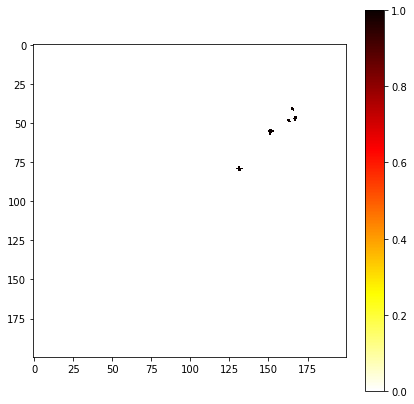

In [12]:
plt.figure(figsize=(7,7))
heatmap = plt.imshow(center_ped_y[nr_future, idx], cmap="hot_r", interpolation='nearest')
plt.colorbar(heatmap)

In [13]:
nr_future = 0

pxl_ped_all = []

for idx2 in range(segm_ped_y.shape[1]):
    
    
    temp_arr = center_ped_y[nr_future, idx2][np.newaxis, :, :]
    temp_arr = temp_arr.astype(np.float32)
    nr_pxls = temp_arr.sum()
    temp_arr[temp_arr == 1] = np.random.uniform(0.9, 1, size = int(nr_pxls))
    
    centers = find_instance_centers(F.Tensor(temp_arr)).cpu().detach().numpy()  ## find_instance_centers did not work when all ones
    nr_elems = len(centers)
    
    #rint(elems)
    
    if(nr_elems == 0):
        if segm_ped_y[nr_future, idx2].sum() != 0:
            print(segm_ped_y[nr_future, idx2].sum(), nr_elems)
        #pxl_ped_all.append(segm_ped_y[nr_future, idx2].sum())
    else:
        pxl_ped = segm_ped_y[nr_future, idx2].sum()/nr_elems
        pxl_ped_all.append(pxl_ped)

In [14]:
bkg_comps = np.median(pxl_ped_all)

(array([  1.,   2.,   0.,   8.,   9.,  48., 111.,  66., 225., 248., 547.,
        424., 542., 491., 261., 179., 114., 240.,  74.,  25.,  74.,  11.,
         25.,   2.,  44.,   7.,   3.,  44.,   2.,   2.,   0.,   9.,   0.,
          0.,   5.,   0.,   0.,   5.,   0.,   0.,   0.,   0.,   0.,   1.,
          1.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1.  ,  1.29,  1.58,  1.87,  2.16,  2.45,  2.74,  3.03,  3.32,
         3.61,  3.9 ,  4.19,  4.48,  4.77,  5.06,  5.35,  5.64,  5.93,
         6.22,  6.51,  6.8 ,  7.09,  7.38,  7.67,  7.96,  8.25,  8.54,
         8.83,  9.12,  9.41,  9.7 ,  9.99, 10.28, 10.57, 10.86, 11.15,
        11.44, 11.73, 12.02, 12.31, 12.6 , 12.89, 13.18, 13.47, 13.76,
        14.05, 14.34, 14.63, 14.92, 15.21, 15.5 ]),
 <BarContainer object of 50 artists>)

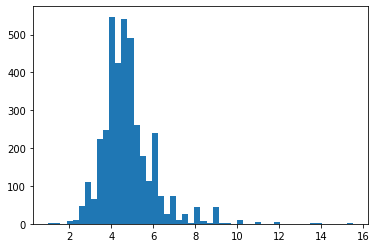

In [15]:
plt.hist(pxl_ped_all, bins=50)

In [16]:
bkg_comps

4.575757575757576

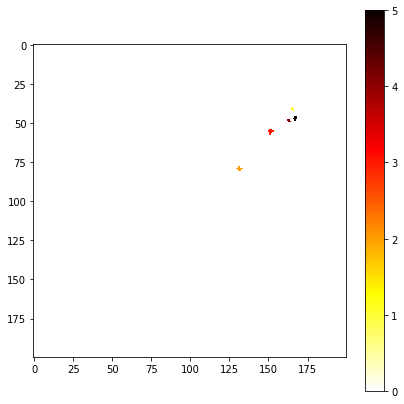

In [17]:
plt.figure(figsize=(7,7))
heatmap = plt.imshow(inst_ped_y[nr_future, idx], cmap="hot_r", interpolation='nearest')
plt.colorbar(heatmap)

In [18]:
inst_ped_y[nr_future, idx].max()

5

In [19]:
nr_future = 0

pxl_ped_all2 = []

for idx2 in range(segm_ped_y.shape[1]):
    
    
    instances = np.unique(inst_ped_y[nr_future, idx2])
    
    for i in instances:
        if i != 0:
            pxl_ped_all2.append(np.sum(inst_ped_y[nr_future, idx2] == i))

In [20]:
for i in range(1, 1):
    print(i)

(array([2.520e+02, 1.060e+03, 2.066e+03, 7.025e+03, 5.613e+03, 5.416e+03,
        2.380e+03, 1.036e+03, 1.516e+03, 2.080e+02, 4.800e+01, 5.600e+01,
        1.200e+01, 2.000e+01, 4.000e+00, 4.000e+00]),
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17.]),
 <BarContainer object of 16 artists>)

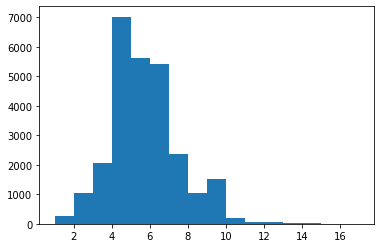

In [21]:
plt.hist(pxl_ped_all2, bins=16)

In [22]:
bkg_comps = np.median(pxl_ped_all2)

In [23]:
pxl_ped_all2

[7,
 6,
 6,
 6,
 5,
 7,
 5,
 5,
 5,
 6,
 5,
 7,
 8,
 6,
 7,
 7,
 8,
 9,
 7,
 7,
 6,
 5,
 8,
 6,
 6,
 7,
 9,
 5,
 4,
 8,
 5,
 9,
 5,
 5,
 6,
 5,
 6,
 6,
 6,
 7,
 7,
 6,
 5,
 5,
 4,
 4,
 7,
 4,
 5,
 6,
 4,
 5,
 7,
 5,
 4,
 6,
 4,
 6,
 5,
 3,
 6,
 6,
 4,
 6,
 5,
 7,
 5,
 6,
 4,
 7,
 6,
 4,
 4,
 5,
 6,
 4,
 5,
 5,
 5,
 7,
 4,
 4,
 5,
 6,
 5,
 5,
 9,
 6,
 5,
 9,
 4,
 3,
 6,
 7,
 5,
 5,
 5,
 6,
 5,
 7,
 9,
 6,
 9,
 6,
 6,
 4,
 6,
 6,
 4,
 4,
 5,
 7,
 5,
 4,
 7,
 6,
 4,
 4,
 5,
 4,
 6,
 4,
 6,
 6,
 4,
 9,
 7,
 6,
 5,
 5,
 4,
 6,
 6,
 4,
 9,
 6,
 4,
 4,
 9,
 6,
 4,
 6,
 5,
 7,
 5,
 6,
 6,
 5,
 6,
 6,
 5,
 4,
 4,
 4,
 5,
 6,
 3,
 5,
 4,
 4,
 7,
 8,
 5,
 4,
 5,
 1,
 5,
 6,
 4,
 6,
 5,
 5,
 5,
 4,
 4,
 4,
 4,
 5,
 7,
 6,
 7,
 4,
 7,
 6,
 5,
 2,
 5,
 6,
 4,
 5,
 6,
 6,
 5,
 5,
 3,
 6,
 7,
 5,
 5,
 4,
 6,
 4,
 5,
 3,
 5,
 6,
 4,
 6,
 4,
 6,
 5,
 7,
 5,
 5,
 5,
 4,
 5,
 4,
 5,
 7,
 4,
 6,
 7,
 6,
 2,
 5,
 6,
 5,
 6,
 5,
 4,
 5,
 5,
 7,
 6,
 5,
 3,
 9,
 6,
 6,
 4,
 7,
 7,
 4,
 8,
 6,
 3,
 2,
 6,
 8,


In [24]:
bkg_comps

5.0

## 3. Match segmentation and norm-distribution

## Testing function for GMM

In [25]:
idx = 200

p, dists, masks, pdfs = find_gaussians(segm_ped_p[0, idx], center_ped_p[0, idx], verbose = True)

Centers: [[ 55 152]
 [147  70]
 [156  64]
 [158  64]
 [166  74]]
3.231116044945954e-33
Pdf: 0.9975955397824037
9.806387993058815e-22
Pdf: 0.9981956016237097
5.344305584917635e-33
Pdf: 0.9980114423879356
3.064270093292588e-08
Pdf: 0.9968346067906362
7.212081574623752e-64
Pdf: 0.994937724147789
[0.91323054 2.285574   1.9064916  0.6398417  2.4811707 ]


In [26]:
p

array([0.91323054, 1.        , 1.        , 0.6398417 , 1.        ],
      dtype=float32)

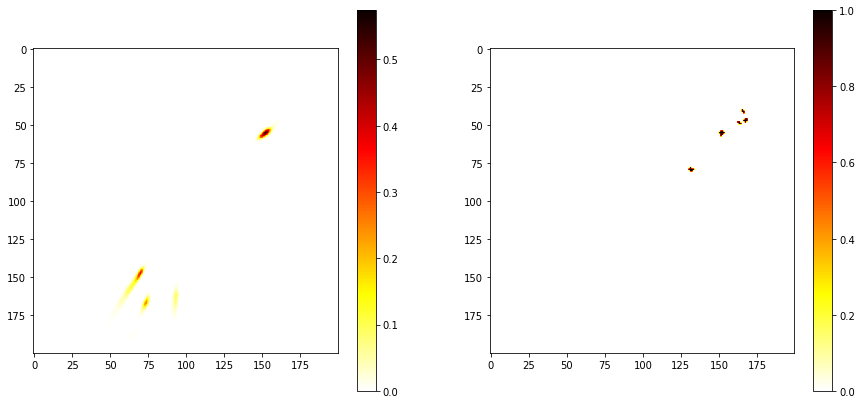

In [27]:
plot_seg(idx, segm_ped_p, segm_ped_y)

## Pixel-wise calibration

In [30]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split


def get_model_cal(p, y, Cal_Fn = IsotonicRegression, nr_future = 0, test_size = 0.8, random_state = 828):

    # 20% for validation (calibration modelling)
    indices_val, indices_test = train_test_split(np.arange(0, p.shape[1]), test_size=test_size, random_state=random_state)

    models = []
    
    masks = [np.ones((200, 200), dtype="bool")]
    
    segm_ped_p_val = p[nr_future, indices_val,]
    segm_ped_y_val = y[nr_future, indices_val,]

    for i, m in enumerate(masks):

        print(i)

        ys_pxl = segm_ped_y_val.reshape(-1) 
        preds_pxl = segm_ped_p_val.reshape(-1)

        print(preds_pxl.shape)
        
        model = Cal_Fn()
        model.fit(preds_pxl, ys_pxl)

        models.append(model)
        
    return models, masks, (indices_val, indices_test)

In [31]:
if True:
    models_cal, masks_cal, (indices_val, indices_test) = \
        get_model_cal(segm_ped_p, segm_ped_y, nr_future = 0, random_state=1001)
    models_cal_c, masks_cal_c, (_, _) =  \
        get_model_cal(center_ped_p, center_ped_y, nr_future = 0, random_state=1001)

0
(40920000,)
0
(40920000,)


In [32]:
if True:
    models_cal_f4, masks_cal_f4, (_, _) = \
        get_model_cal(segm_ped_p, segm_ped_y, nr_future = 4, random_state=1001)
    models_cal_c_f4, masks_cal_c_f4, (_, _) =  \
        get_model_cal(center_ped_p, center_ped_y, nr_future = 4, random_state=1001)

0
(40920000,)
0
(40920000,)


In [28]:
if False:
    models_cal, masks_cal, (indices_val, indices_test) = \
        get_models_in_rings(segm_ped_p, segm_ped_y, nr_future = 0, random_state=1001)
    models_cal_c, masks_cal_c, (_, _) =  \
        get_models_in_rings(center_ped_p, center_ped_y, nr_future = 0, random_state=1001)

In [29]:
if False:
    models_cal_f4, masks_cal_f4, (_, _) = \
        get_models_in_rings(segm_ped_p, segm_ped_y, nr_future = 4, random_state=1001)
    models_cal_c_f4, masks_cal_c_f4, (_, _) =  \
        get_models_in_rings(center_ped_p, center_ped_y, nr_future = 4, random_state=1001)

In [33]:
def get_presence_probs(segm_ped_p, segm_ped_y, center_ped_p, indices_inp, nr_future = 0,
                       models_cal = models_cal, masks_cal = masks_cal, models_cal_c = models_cal_c, 
                       masks_cal_c = masks_cal_c, calib_gmm = False, val_pixels = 40920000):

    probs_cal = []
    probs = []
    ys = []
    #FNs = []
    dist_means = []
    indices = []

    #nr_future = 0

    print("Nr future = ", nr_future)
    
    for count, idx in enumerate(indices_inp):
        
        #print(idx)

        if count % 100 == 0:
            print(count)


        segm_cal_full = np.zeros(shape=masks_cal[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))
            
            segm_cal_2d[np.isnan(segm_cal_2d)] = 1/val_pixels
            segm_cal_2d = np.clip(segm_cal_2d, 1/val_pixels, 1)
            segm_cal_2d = segm_cal_2d.astype("float64")

            segm_cal_full[mask] = segm_cal_2d[mask]   

        if calib_gmm:
            
            center_cal_full = np.zeros(shape=masks_cal_c[0].shape)
            
            for model_c, mask_c in zip(models_cal_c, masks_cal_c):
                center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
                center_cal_2d = center_cal.reshape(200,200)

                center_cal_2d[np.isnan(center_cal_2d)] = 1/val_pixels
                center_cal_2d = np.clip(center_cal_2d, 1/val_pixels, 1)
                center_cal_2d = center_cal_2d.astype("float64")

                center_cal_full[mask_c] = center_cal_2d[mask_c]

            center_ped_p_new = center_cal_full.copy()
            
            segm_p_new = segm_cal_full.copy()  # Both inputs calibrated
            segm_p_cal_new = segm_cal_full.copy()
            
        else:
            
            center_ped_p_new = center_ped_p[nr_future, idx].copy()
            segm_p_new = segm_ped_p[nr_future, idx].copy()
            segm_p_cal_new = segm_cal_full.copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_new, segm_p_cal_new, center_ped_p_new, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[nr_future, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            #print(pred_cl)

            all_matches.append([[], [], [pr], [pr_cal], [dist.mean], [idx]])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][0].append(n_cl)
                    all_matches[i][1].append(match_prob)

        for res in all_matches:
            probs.append(res[2][0])
            probs_cal.append(res[3][0])
            dist_means.append(res[4])
            ys.append(0 if len(res[0]) == 0 else 1)
            indices.append(res[5])
        #break
    
    
    #print(dist_means)
    
    dist_means = np.array(dist_means)[:, -1, :]
    probs = np.array(probs)
    probs_cal = np.array(probs_cal)
    ys = np.array(ys)
    indices = np.array(indices)[:, -1]
    
    np.savez("results_all_presence_uncertainty%s_n=%i_09_27_22_pw.npz" % (("_cal" if calib_gmm else ""), nr_future), 
             p=probs, p_cal=probs_cal, y=ys, dist_mean=dist_means, indices=indices)
    
    return probs, probs_cal, ys, indices, dist_means

In [34]:
def get_val_test(probs, ys, indices, indices_test = indices_test, indices_val = indices_val):
## Get test indices

    all_indices_test = []
    all_indices_val = []

    for i in indices_test:
        all_indices_test += list(np.where(i == indices)[0])

    for i in indices_val:
        all_indices_val += list(np.where(i == indices)[0])

    all_indices_test = np.array(all_indices_test)
    all_indices_test.sort()

    all_indices_val = np.array(all_indices_val)
    all_indices_val.sort()
    
    return (probs[all_indices_val], ys[all_indices_val]), (probs[all_indices_test], ys[all_indices_test])

In [35]:
from betacal import BetaCalibration

def cal_obj(probs_val, probs_test, ys_val, ys_test):
    
    model = BetaCalibration()
    model.fit(probs_val, ys_val)
    
    probs_test_objcal = model.predict(probs_test)
    
    return probs_test_objcal

In [36]:
probs, probs_cal, ys, indices, dist_means = get_presence_probs(segm_ped_p, segm_ped_y, center_ped_p, indices_inp = range(0, segm_ped_p.shape[1]), nr_future = 0)

Nr future =  0
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [37]:
probs2, probs_cal2, ys2, indices2, dist_means2 = get_presence_probs(segm_ped_p, segm_ped_y, center_ped_p, 
                                                                    range(0, segm_ped_p.shape[1]), 
                                                                    nr_future = 0, calib_gmm = True)

Nr future =  0
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [38]:
probs_f4, probs_cal_f4, ys_f4, indices_f4, dist_means_f4 = get_presence_probs(segm_ped_p, segm_ped_y, center_ped_p, 
                                                                              range(0, segm_ped_p.shape[1]), nr_future = 4, 
                                                                              calib_gmm = False,
                                                                              models_cal = models_cal_f4, masks_cal = masks_cal_f4,
                                                                              models_cal_c = models_cal_c_f4, 
                                                                              masks_cal_c = masks_cal_c_f4)

Nr future =  4
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [39]:
probs2_f4, probs_cal2_f4, ys2_f4, indices2_f4, dist_means2_f4 = get_presence_probs(segm_ped_p, segm_ped_y, 
                                                                                   center_ped_p, range(0, segm_ped_p.shape[1]), 
                                                                                   nr_future = 4, calib_gmm = True,
                                                                                   models_cal = models_cal_f4, 
                                                                                   masks_cal = masks_cal_f4,
                                                                                   models_cal_c = models_cal_c_f4, 
                                                                                   masks_cal_c = masks_cal_c_f4)

Nr future =  4
0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100


In [96]:
(probs_val, ys_val), (probs_test, ys_test) = get_val_test(probs, ys, indices)
(probs_cal_val, _), (probs_cal_test, _) = get_val_test(probs_cal, ys, indices)

In [ ]:
(probs2_val, ys2_val), (probs2_test, ys2_test) = get_val_test(probs2, ys2, indices2)
(probs2_cal_val, _), (probs2_cal_test, _) = get_val_test(probs_cal2, ys2, indices2)

In [ ]:
#(probs_val_f4, ys_val_f4), (probs_test_f4, ys_test_f4) = get_val_test(probs_f4, ys_f4, indices_f4)
#(probs_cal_val_f4, _), (probs_cal_test_f4, _) = get_val_test(probs_cal_f4, ys_f4, indices_f4)

In [ ]:
#(probs2_val_f4, ys2_val_f4), (probs2_test_f4, ys2_test_f4) = get_val_test(probs2_f4, ys2_f4, indices2_f4)
#(probs2_cal_val_f4, _), (probs2_cal_test_f4, _) = get_val_test(probs_cal2_f4, ys2_f4, indices2_f4)

In [30]:
# Load data

res_pres_cal = np.load("results_all_presence_uncertainty_n=0_09_27_22.npz")

probs = res_pres_cal["p"]
probs_cal = res_pres_cal["p_cal"]
ys = res_pres_cal["y"]
dist_means = res_pres_cal["dist_mean"]
indices = res_pres_cal["indices"]


ECE_abs: 0.1838914146721039
[361, 344, 318, 290, 256, 267, 261, 226, 239, 11248]
Conf: [0.052952472, 0.14810267, 0.24609073, 0.34698603, 0.4479219, 0.5513695, 0.6480344, 0.7482659, 0.85066503, 0.9988788]
Acc: [0.06925207756232687, 0.13372093023255813, 0.1949685534591195, 0.2793103448275862, 0.36328125, 0.3445692883895131, 0.3333333333333333, 0.37168141592920356, 0.42677824267782427, 0.8079658605974396]


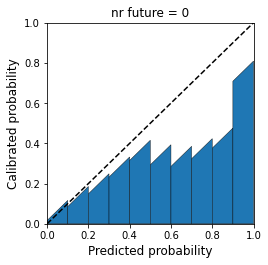

In [109]:
generate_rel_diagrams(np.clip(probs_test, 0, 1), ys_test)


ECE_abs: 0.12265214329371216
[491, 504, 453, 444, 498, 482, 502, 455, 511, 9470]
Conf: [0.05255281074601107, 0.1493172842557632, 0.24954711292598664, 0.3498146516698, 0.4493637160374204, 0.5482421004285931, 0.6497688369913296, 0.7493052037977642, 0.8505207855579067, 0.9973340152502175]
Acc: [0.07739307535641547, 0.1746031746031746, 0.23841059602649006, 0.2882882882882883, 0.3313253012048193, 0.4896265560165975, 0.5298804780876494, 0.5230769230769231, 0.6105675146771037, 0.8638859556494192]


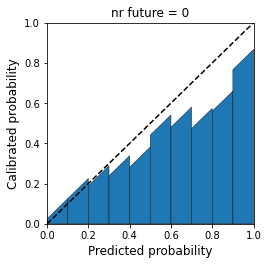

In [110]:
generate_rel_diagrams(np.clip(probs_cal_test, 0, 1), ys_test)

### Object-wise calibration

In [134]:
indices_val[:10]

array([3275,  877,  678,  292, 3822,  741, 3479,  288,  709, 4469])

In [122]:
probs_test_objcal = cal_obj(probs_val, probs_test, ys_val, ys_test)


ECE_abs: 0.018211231742214697
[279, 642, 732, 757, 359, 34, 1, 0, 11006, 0]
Conf: [0.06151809608989296, 0.15103715821246136, 0.24974874236926908, 0.34596912557395393, 0.4380194281773135, 0.5285337884309407, 0.603868086270717, nan, 0.8330175479727889, nan]
Acc: [0.04659498207885305, 0.1542056074766355, 0.296448087431694, 0.36988110964332893, 0.4233983286908078, 0.4117647058823529, 0.0, nan, 0.8163728875159004, nan]


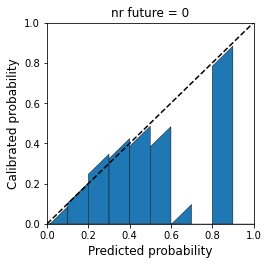

In [123]:
generate_rel_diagrams(probs_test_objcal, ys_test)

In [42]:
# TODO check how the coordinates relate? Is a correct area selected
# Dist means, in which format?

In [43]:
area = np.array([[39,101],[69,131]])
indices_area = np.where((dist_means[:, 0] >= area[0][0]) & (dist_means[:, 0] < area[0][1]) & (dist_means[:, 1] >= area[1][0]) & (dist_means[:, 1] < area[1][1]))

In [44]:
area = np.array([[79,101],[79,121]])
indices_area = np.where((dist_means[:, 0] >= area[0][0]) & (dist_means[:, 0] < area[0][1]) & (dist_means[:, 1] >= area[1][0]) & (dist_means[:, 1] < area[1][1]))


ECE_abs: 0.04730007275804825
[7, 3, 8, 5, 11, 8, 7, 8, 13, 763]
Conf: [0.030292032, 0.15012378, 0.2407418, 0.3305494, 0.45113373, 0.56189036, 0.65968376, 0.7422813, 0.83925825, 0.99943125]
Acc: [0.14285714285714285, 0.3333333333333333, 0.875, 1.0, 1.0, 0.875, 0.8571428571428571, 0.875, 0.8461538461538461, 0.9750982961992136]


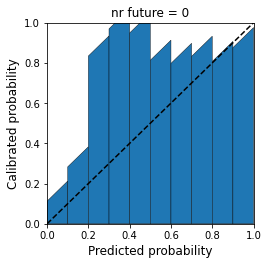

In [45]:
generate_rel_diagrams(np.clip(probs, 0, 1)[indices_area[0]], ys[indices_area[0]])

Praegu GMM'd leitud kalibreerimata andmete põhjal ja otseselt võrreldud neid


ECE_abs: 0.044395636045761494
[5, 3, 4, 6, 6, 10, 9, 8, 10, 772]
Conf: [0.01450470288565808, 0.17575750323104952, 0.23892133339335714, 0.36555066996046387, 0.4541059935343965, 0.5626491848010997, 0.6589921917995452, 0.7547458517856349, 0.8494061919928511, 0.9991236474297631]
Acc: [0.0, 0.3333333333333333, 0.5, 1.0, 1.0, 1.0, 0.8888888888888888, 0.625, 1.0, 0.9740932642487047]


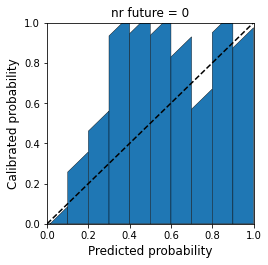

In [46]:
generate_rel_diagrams(np.clip(probs_cal, 0, 1)[indices_area[0]], ys[indices_area[0]])

## Calibrated segm for GMM

In [47]:
if False:

    probs_cal2 = []
    probs2 = []
    ys2 = []
    dist_means2 = []
    indices2 = []

    nr_future = 0

    for count, idx in enumerate(indices_test):

        if count % 100 == 0:
            print(count)

        # Calib
        segm_cal_full = np.zeros(shape=masks_cal[0].shape)
        center_cal_full = np.zeros(shape=masks_cal_c[0].shape)

        for model, mask in zip(models_cal, masks_cal):
            segm_cal = model.predict(segm_ped_p[nr_future, idx].flatten())
            segm_cal_2d = segm_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            segm_cal_full[mask] = segm_cal_2d[mask]

        for model_c, mask_c in zip(models_cal_c, masks_cal_c):
            center_cal = model_c.predict(center_ped_p[nr_future, idx].flatten())
            center_cal_2d = center_cal.reshape(200,200)

            #print("Uncal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_ped_p[nr_future, idx].flatten()))
            #print("Cal NLL:", log_loss(segm_ped_y[nr_future, idx].flatten(), segm_cal))

            center_cal_full[mask_c] = center_cal_2d[mask_c]

        center_p_cal = center_cal_full.copy()
        segm_p_new = segm_ped_p[nr_future, idx].copy()
        segm_p_cal_new = segm_cal_full.copy()
        #center_ped_p_new = center_ped_p[nr_future, idx].copy()

        p, p_cal, dists, masks_gmm, pdfs = find_gaussians_cal(segm_p_cal_new, segm_p_cal_new, center_p_cal, 
                                                                      multiplier = 100, conf_threshold=0.1, nms_kernel_size=3)
        cls = get_clusters(segm_ped_y[0, idx])

        ## Match cls with predicted cls
        all_matches = []
        all_matches_cal = []

        if masks_gmm == None:
            continue

        for i, (pr, pr_cal, dist, m) in enumerate(zip(p, p_cal, dists, masks_gmm)):

            #print(pred_cl)

            all_matches.append([[], [], [pr], [pr_cal], [dist.mean], [idx]])

            for n_cl, cl in enumerate(cls):
                matches = np.sum(m[np.array(cl)[:, 1], np.array(cl)[:, 0]])
                match_prob = matches/len(cl)

                if matches != 0:
                    all_matches[i][0].append(n_cl)
                    all_matches[i][1].append(match_prob)

        for res in all_matches:
            probs2.append(res[2][0])
            probs_cal2.append(res[3][0])
            dist_means2.append(res[4])
            ys2.append(0 if len(res[0]) == 0 else 1)
            indices2.append(res[5])
        #break

    dist_means2 = np.array(dist_means2)[:, -1, :]
    probs2 = np.array(probs2)
    probs_cal2 = np.array(probs_cal2)
    ys2 = np.array(ys2)
    indices2 = np.array(indices2)[:, -1]

    np.savez("results_presence_uncertainty_cal_09_23_22_v2.npz", p=None, p_cal=probs2, 
              y = ys2, dist_mean = dist_means2, indices = indices2)

In [48]:

res_pres_cal = np.load("results_presence_uncertainty_cal_09_23_22_v2.npz")

#probs2 = res_pres_cal["p"]
probs2 = res_pres_cal["p_cal"]
ys2 = res_pres_cal["y"]
dist_means2 = res_pres_cal["dist_mean"]
indices2 = res_pres_cal["indices"]


ECE_abs: 0.0643102732422846
[58, 89, 86, 90, 109, 113, 139, 162, 187, 6883]
Conf: [0.062168784963007144, 0.148741456337909, 0.2486871908428818, 0.34432848073259503, 0.4507256195346758, 0.5525013881816948, 0.6497774406153373, 0.7514131579420711, 0.850215653625702, 0.998371583358477]
Acc: [0.06896551724137931, 0.1797752808988764, 0.18604651162790697, 0.35555555555555557, 0.3211009174311927, 0.5929203539823009, 0.5683453237410072, 0.6851851851851852, 0.7540106951871658, 0.9343309603370623]


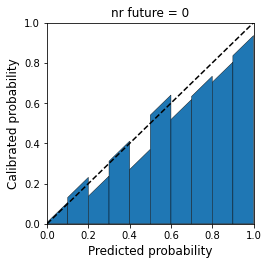

In [49]:
generate_rel_diagrams(np.clip(np.array(probs2), 0, 1), np.array(ys2))

In [50]:
area = np.array([[79,101],[79,121]])
indices_area = np.where((dist_means2[:, 0] >= area[0][0]) & (dist_means2[:, 0] < area[0][1]) & (dist_means2[:, 1] >= area[1][0]) & (dist_means2[:, 1] < area[1][1]))


ECE_abs: 0.017654069955596166
[3, 0, 0, 1, 0, 3, 2, 6, 6, 691]
Conf: [0.03641703444675026, nan, nan, 0.39553308384222785, nan, 0.5429917327209521, 0.680339496289615, 0.7552744078344745, 0.8448407375951961, 0.9994021389521067]
Acc: [0.0, nan, nan, 1.0, nan, 1.0, 0.5, 0.8333333333333334, 0.8333333333333334, 0.9855282199710564]


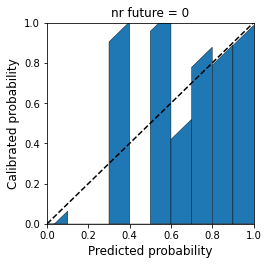

In [51]:
generate_rel_diagrams(np.clip(probs2, 0, 1)[indices_area[0]], ys2[indices_area[0]])